Dataset chargé : 900 lignes, 8 colonnes
label
rice        100
plantain    100
coconut     100
cacao       100
igname      100
maize       100
coffee      100
anacarde    100
cotton      100
Name: count, dtype: int64

Features (X) : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Target (y) : 9 classes -> ['anacarde', 'cacao', 'coconut', 'coffee', 'cotton', 'igname', 'maize', 'plantain', 'rice']

 Correspondance label <-> code 
0 -> anacarde
1 -> cacao
2 -> coconut
3 -> coffee
4 -> cotton
5 -> igname
6 -> maize
7 -> plantain
8 -> rice

Train : 720 lignes
Test  : 180 lignes

 Validation croisée (5 folds) 


/home/agrefirmin/C-DAT-900-ABJ-2-2-ecp-8/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/agrefirmin/C-DAT-900-ABJ-2-2-ecp-8/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https

Logistic Regression       -> Accuracy moyenne : 0.9597 (+/- 0.0167)
LinearSVC                 -> Accuracy moyenne : 0.9500 (+/- 0.0092)
Random Forest             -> Accuracy moyenne : 0.9861 (+/- 0.0044)
Gradient Boosting         -> Accuracy moyenne : 0.9722 (+/- 0.0076)

 Évaluation sur le jeu de test 


/home/agrefirmin/C-DAT-900-ABJ-2-2-ecp-8/.env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



 Logistic Regression 
Accuracy test : 0.9389

 LinearSVC 
Accuracy test : 0.9333

 Random Forest 
Accuracy test : 0.9833

 Gradient Boosting 
Accuracy test : 0.9722


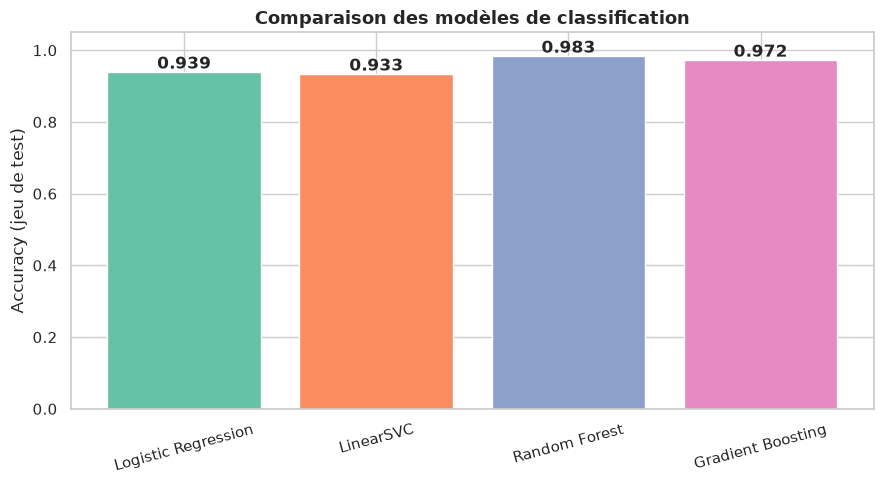


 Meilleur modèle : Random Forest (accuracy = 0.9833)

 Rapport de classification — Random Forest 
              precision    recall  f1-score   support

    anacarde       1.00      1.00      1.00        20
       cacao       1.00      0.95      0.97        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      igname       0.95      0.90      0.92        20
       maize       1.00      1.00      1.00        20
    plantain       0.91      1.00      0.95        20
        rice       1.00      1.00      1.00        20

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180



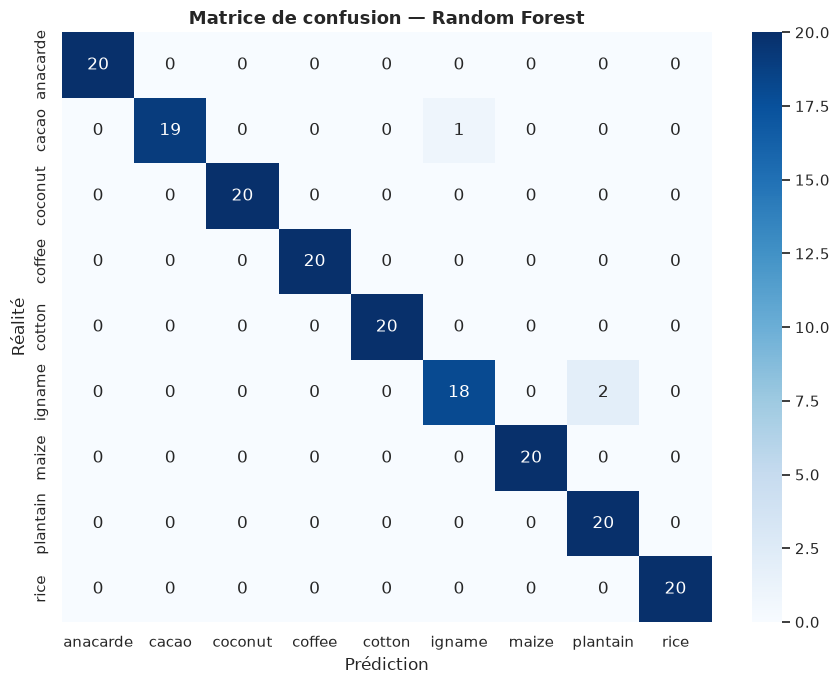

/tmp/ipykernel_3162/1180811528.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


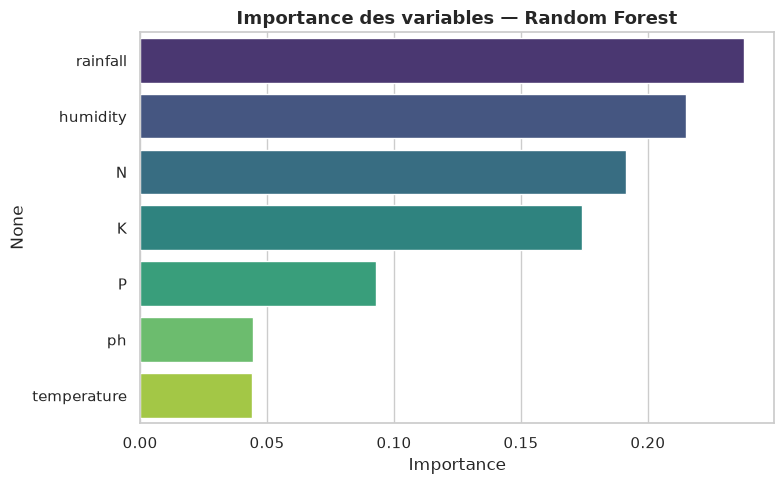


 Importance des variables 
rainfall       0.237774
humidity       0.215187
N              0.191286
K              0.174198
P              0.092901
ph             0.044600
temperature    0.044055
dtype: float64


['../models/label_encoder.joblib']

In [ ]:
# Prétraitement + Entraînement des modèles de classification
# Dataset : dataset_agricole_ci_final.csv (9 cultures, 1000 lignes)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

# 1. CHARGEMENT DES DONNÉES

df = pd.read_csv('../data/dataset_agricole_ci_final.csv')
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(df['label'].value_counts())

# 2. SÉPARATION FEATURES / TARGET

# X = les 7 variables agronomiques (ce que l'utilisateur soumettra dans l'app)
X = df.drop(columns=['label'])

# y = la culture à prédire
y = df['label']

print(f"\nFeatures (X) : {X.columns.tolist()}")
print(f"Target (y) : {y.nunique()} classes -> {sorted(y.unique())}")

# 3. ENCODAGE DE LA TARGET
# Les modèles ML ont besoin de labels numériques, pas de texte
# On garde le LabelEncoder pour pouvoir retraduire les prédictions
# en noms de cultures plus tard dans l'API


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\n Correspondance label <-> code ")
for i, classe in enumerate(label_encoder.classes_):
    print(f"{i} -> {classe}")

# 4. SPLIT TRAIN / TEST
# Stratifié : garde les proportions de chaque culture identiques
# dans le train et le test (important car 9 classes équilibrées)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

# 5. DÉFINITION DES MODÈLES À COMPARER
# Pas besoin de TF-IDF ici : les features sont déjà numériques

modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC": LinearSVC(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 6. ENTRAÎNEMENT ET VALIDATION CROISÉE

resultats = {}

print("\n Validation croisée (5 folds) ")
for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_train, y_train, cv=5, scoring='accuracy')
    resultats[nom] = scores.mean()
    print(f"{nom:25s} -> Accuracy moyenne : {scores.mean():.4f} (+/- {scores.std():.4f})")

# 7. ENTRAÎNEMENT FINAL SUR TOUT LE TRAIN ET ÉVALUATION SUR LE TEST

print("\n Évaluation sur le jeu de test ")
predictions = {}
accuracies_test = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    predictions[nom] = y_pred
    accuracies_test[nom] = acc
    print(f"\n {nom} ")
    print(f"Accuracy test : {acc:.4f}")

# 8. COMPARAISON VISUELLE DES MODÈLES

plt.figure(figsize=(9, 5))
noms = list(accuracies_test.keys())
valeurs = list(accuracies_test.values())
colors = sns.color_palette("Set2", len(noms))

bars = plt.bar(noms, valeurs, color=colors)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy (jeu de test)")
plt.title("Comparaison des modèles de classification", fontsize=13, fontweight='bold')
plt.xticks(rotation=15)

# Affiche la valeur au-dessus de chaque barre
for bar, val in zip(bars, valeurs):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
              f"{val:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 9. SÉLECTION DU MEILLEUR MODÈLE

meilleur_nom = max(accuracies_test, key=accuracies_test.get)
meilleur_modele = modeles[meilleur_nom]

print(f"\n Meilleur modèle : {meilleur_nom} (accuracy = {accuracies_test[meilleur_nom]:.4f})")


# 10. RAPPORT DE CLASSIFICATION DÉTAILLÉ DU MEILLEUR MODÈLE


y_pred_final = predictions[meilleur_nom]

print(f"\n Rapport de classification - {meilleur_nom} ")
print(classification_report(
    y_test, y_pred_final,
    target_names=label_encoder.classes_
))


# 11. MATRICE DE CONFUSION DU MEILLEUR MODÈLE
# Permet de voir précisément quelles cultures sont confondues entre elles


cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Matrice de confusion - {meilleur_nom}", fontsize=13, fontweight='bold')
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.tight_layout()
plt.show()


# 12. FEATURE IMPORTANCE (si le modèle le permet)
# Montre quelles variables comptent le plus dans la décision


if hasattr(meilleur_modele, 'feature_importances_'):
    importances = pd.Series(
        meilleur_modele.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(f"Importance des variables - {meilleur_nom}", fontsize=13, fontweight='bold')
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("\n Importance des variables ")
    print(importances)
else:
    print(f"\n({meilleur_nom} ne fournit pas de feature_importances_ directement)")

# 13. SAUVEGARDE DU MODÈLE FINAL ET DU LABEL ENCODER
# Ces deux fichiers seront chargés par l'API FastAPI

import os
os.makedirs('../models', exist_ok=True)

joblib.dump(meilleur_modele, '../models/modele_recommandation_culture.joblib')
joblib.dump(label_encoder, '../models/label_encoder.joblib')